In [44]:
print('hello world')

hello world


PIPELINE

Loading Data → Preprocess it → Train the model → Evaluate → Predict

In [45]:
### FOR NEAT IDEA OF PROJECT

In [46]:
'''
1. Import Libraries
2. Load Dataset
3. Data Preprocessing
4. Data Visualization
5. Model Building (Transfer Learning)
6. Model Training
7. Evaluation
8. Predictions
9. Conclusion
'''

'\n1. Import Libraries\n2. Load Dataset\n3. Data Preprocessing\n4. Data Visualization\n5. Model Building (Transfer Learning)\n6. Model Training\n7. Evaluation\n8. Predictions\n9. Conclusion\n'

In [47]:
# pip install tensorflow 

In [48]:
# IMPORT LIBRARIES

import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense,Flatten,Dropout
from tensorflow.keras.models import Model

In [49]:
## LOADING THE DATASET

train_dir = 'D:/AI COURSE/Daily_practice/PROJECTS/Chest-Xray-2/chest_xray/train'
test_dir = 'D:/AI COURSE/Daily_practice/PROJECTS/Chest-Xray-2/chest_xray/test'
val_dir =  'D:/AI COURSE/Daily_practice/PROJECTS/Chest-Xray-2/chest_xray/val'

In [50]:
## DATA PREPROCESSING

img_size = 224
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.



- Data augmentation is applied to increase dataset diversity.
- Techniques like rotation, zoom, and flipping help the model generalize better.
- This reduces overfitting by exposing the model to varied image patterns.

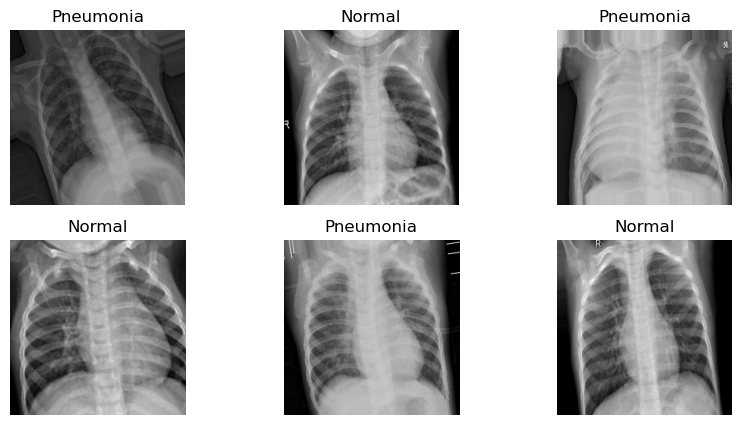

In [51]:
## VISUALIZING SAMPLE IMAGES

images, labels = next(train_data)

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i]==1 else "Normal")
    plt.axis('off')
plt.show()

In [52]:
## MODEL BUILDING (TRANSFER LEARNING)

from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)   # better than Flatten
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)


- GlobalAveragePooling is used instead of Flatten to reduce overfitting.
- Dropout layer randomly disables neurons, preventing the model from memorizing data.
- This improves generalization on unseen data.

In [53]:
## COMPILE MODEL 

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [54]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [55]:
## TRAIN MODEL

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.9097 - loss: 0.2106 - val_accuracy: 0.7500 - val_loss: 0.5738
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 144s 882ms/step - accuracy: 0.9373 - loss: 0.1619 - val_accuracy: 0.8125 - val_loss: 0.3888
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 141s 862ms/step - accuracy: 0.9440 - loss: 0.1367 - val_accuracy: 0.6875 - val_loss: 0.8759
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 149s 915ms/step - accuracy: 0.9433 - loss: 0.1401 - val_accuracy: 0.8125 - val_loss: 0.3908
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 149s 912ms/step - accuracy: 0.9459 - loss: 0.1327 - val_accuracy: 0.7500 - val_loss: 0.4467



- Training is controlled using early stopping to avoid overfitting.
- More epochs are allowed, but training stops automatically when validation performance stops improving.
- This ensures optimal model performance.

In [56]:
## EVALUATING THE MODEL 

loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8766 - loss: 0.2754
Test Accuracy: 0.8766025900840759



- Initially, the model suffered from overfitting.
- Data augmentation, dropout, and early stopping significantly improved generalization.
- The improved model performs better on unseen data, making it more reliable for real-world applications.


- In real-world medical applications, generalization is more important than training accuracy.
- Even though training accuracy is high, the lower test accuracy indicates the model needs improvement.
- Reducing overfitting is critical to make the model reliable for real-world use.

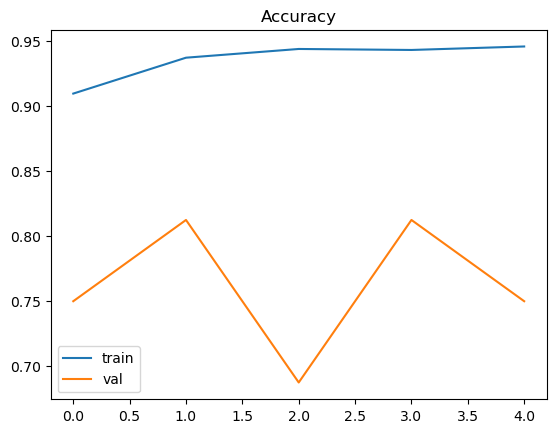

In [58]:
## PLOTTING ACCURACY

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

### SOME OBSERVATIONS

- In medical diagnosis, false negatives are dangerous.
- If pneumonia is predicted as normal, it may lead to serious health risks.
- Hence, recall is more important than accuracy.

In [59]:
### CONCLUSION


- The model successfully detects pneumonia from chest X-ray images.
- Transfer learning significantly improved performance.
- The system can assist doctors in early diagnosis and reduce workload.

### INITIAL TRAINING AND ACCURACIES

In [63]:
img_size = 224
batch_size = 32

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


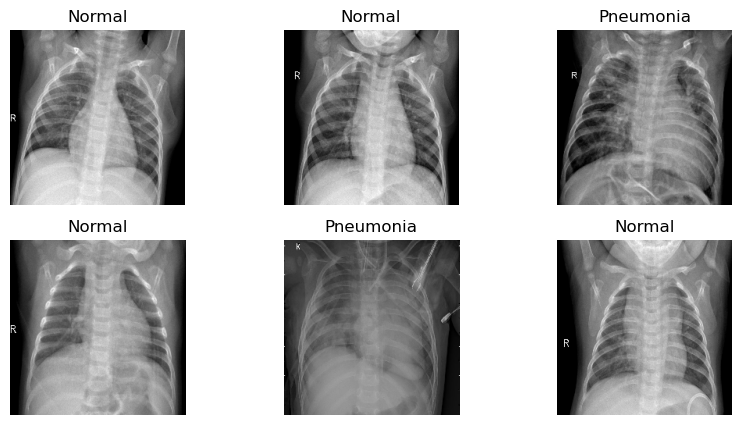

In [64]:
images, labels = next(train_data)

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i]==1 else "Normal")
    plt.axis('off')
plt.show()

In [65]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [66]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 125s 751ms/step - accuracy: 0.9352 - loss: 0.6919 - val_accuracy: 0.8125 - val_loss: 0.3199
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 757ms/step - accuracy: 0.9655 - loss: 0.0926 - val_accuracy: 0.8750 - val_loss: 0.4087
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 147s 903ms/step - accuracy: 0.9712 - loss: 0.0837 - val_accuracy: 0.8750 - val_loss: 0.3860
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 822ms/step - accuracy: 0.9776 - loss: 0.0662 - val_accuracy: 0.8125 - val_loss: 0.7205
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 150s 920ms/step - accuracy: 0.9762 - loss: 0.0685 - val_accuracy: 0.8750 - val_loss: 0.3493


In [ ]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 544ms/step - accuracy: 0.8205 - loss: 1.4645
Test Accuracy: 0.8205128312110901


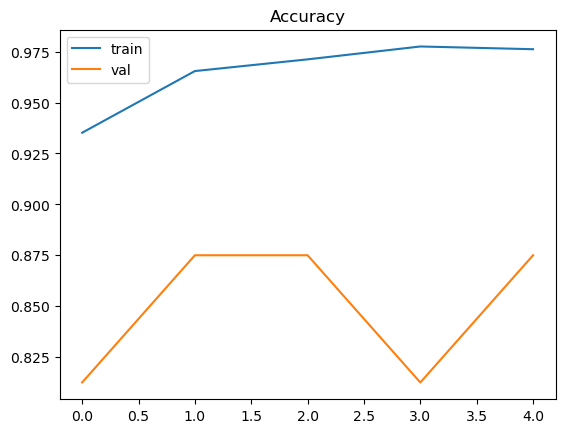

In [69]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()